# 3.2 — Model Analysis & Explanation (Best Pipeline)

This notebook analyses and explains the winning **(dataset × model)** pair selected in `3.1-Data-Modelling-Regression.ipynb`.

It loads all trained results from the shared cache (`./models/all_results_cache.joblib`) so it  
**can be run independently** — no need to re-train anything.

## Outline

| # | Section |
|---|---|
| 1 | Imports & load best pipeline from cache |
| 2 | Residual analysis — best pipeline |
| 3 | Feature importance & SHAP — best pipeline |
| 4 | Dummy patient prediction — best pipeline |
| 5 | Save all models and metrics |

## 1. Imports & Load Best Pipeline from Cache

In [1]:
from pathlib import Path
import joblib
import pandas as pd
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import shap
except Exception:
    shap = None

pd.options.display.max_columns = 200
pd.options.display.precision   = 4

print('Libraries loaded. SHAP available:', shap is not None)

c:\Users\mittall\source\EAISI\NHS\EAISI-NHS\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded. SHAP available: True


In [2]:
# ── Load results cache produced by 3.1 ───────────────────────────────────────
_RESULTS_PATH = Path('./models/all_results_cache.joblib')

if not _RESULTS_PATH.exists():
    raise FileNotFoundError(
        f"Cache not found at {_RESULTS_PATH}.\n"
        "Run 3.1-Data-Modelling-Regression.ipynb first to train and cache all models."
    )

all_results = joblib.load(_RESULTS_PATH)
print(f'Loaded {sum(len(v) for v in all_results.values())} cached runs from {_RESULTS_PATH}')
for ds, models_dict in all_results.items():
    for mdl, r in models_dict.items():
        print(f'  ✓  {ds:20s} × {mdl:<20s}  Test RMSE={r["test_rmse"]:.4f}  R²={r["test_r2"]:.4f}')

Loaded 10 cached runs from models\all_results_cache.joblib
  ✓  2.1-Manual           × LinearRegression      Test RMSE=8.1271  R²=0.3136
  ✓  2.1-Manual           × Ridge                 Test RMSE=8.1245  R²=0.3141
  ✓  2.1-Manual           × Lasso                 Test RMSE=8.1271  R²=0.3137
  ✓  2.1-Manual           × RandomForest          Test RMSE=5.6459  R²=0.6688
  ✓  2.1-Manual           × GradientBoosting      Test RMSE=5.5348  R²=0.6817
  ✓  2.1-Manual           × XGBoost               Test RMSE=5.5349  R²=0.6817
  ✓  2.2-UMAP-MICE        × LinearRegression      Test RMSE=8.8854  R²=0.1796
  ✓  2.2-UMAP-MICE        × Ridge                 Test RMSE=8.8815  R²=0.1803
  ✓  2.2-UMAP-MICE        × Lasso                 Test RMSE=8.8798  R²=0.1806
  ✓  2.2-UMAP-MICE        × XGBoost               Test RMSE=8.7987  R²=0.1955


In [4]:

# ── Rebuild comparison table and identify winner ──────────────────────────────
comparison_rows = []
for ds_label, models_dict in all_results.items():
    for mdl_name, res in models_dict.items():
        comparison_rows.append({
            'Dataset':   ds_label,
            'Model':     mdl_name,
            'CV RMSE':   round(res['cv_rmse'],   4),
            'CV R²':     round(res['cv_r2'],      4),
            'Test MAE':  round(res['test_mae'],   4),
            'Test RMSE': round(res['test_rmse'],  4),
            'Test R²':   round(res['test_r2'],    4),
        })

comparison_df = (
    pd.DataFrame(comparison_rows)
    .sort_values('Test RMSE')
    .reset_index(drop=True)
)

winner_row   = comparison_df.iloc[0]
best_dataset = winner_row['Dataset']
best_name    = winner_row['Model']

best_res      = all_results[best_dataset][best_name]
best_pipeline = best_res['pipeline']
X_train       = best_res['X_train']
X_test        = best_res['X_test']
y_train       = best_res['y_train']
y_test        = best_res['y_test']
y_pred        = best_res['y_pred']
feature_names = best_res['feature_names']
numeric_cols  = best_res['numeric_cols']
cat_cols      = best_res['cat_cols']

print(f'\n>>> OVERALL WINNER')
print(f'    Dataset  : {best_dataset}')
print(f'    Model    : {best_name}')
print(f'    Test RMSE: {winner_row["Test RMSE"]}  |  Test R²: {winner_row["Test R²"]}')
print(f'\nSections 2–5 will use: dataset={best_dataset}, model={best_name}')



>>> OVERALL WINNER
    Dataset  : 2.1-Manual
    Model    : GradientBoosting
    Test RMSE: 5.5348  |  Test R²: 0.6817

Sections 2–5 will use: dataset=2.1-Manual, model=GradientBoosting


## 2. Residual Analysis — Best Pipeline

Using the winning **(dataset, model)** pair identified above.

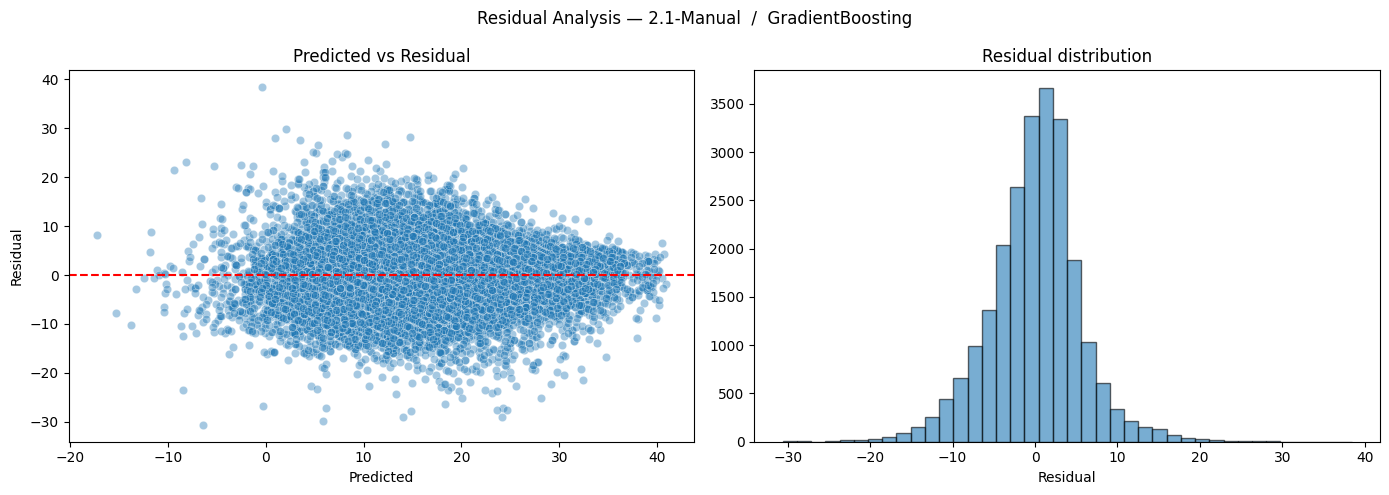

Residual stats: mean=-0.0544  std=5.5345


In [5]:
resid = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Residual Analysis — {best_dataset}  /  {best_name}', fontsize=12)

sns.scatterplot(ax=axes[0], x=y_pred, y=resid, alpha=0.4)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residual')
axes[0].set_title('Predicted vs Residual')

axes[1].hist(resid, bins=40, edgecolor='k', alpha=0.6)
axes[1].set_title('Residual distribution')
axes[1].set_xlabel('Residual')

plt.tight_layout()
plt.show()

print(f'Residual stats: mean={resid.mean():.4f}  std={resid.std():.4f}')

## 3. Feature Importance & SHAP — Best Pipeline

Top 20 feature importances:


Knee Replacement Pre-Op Q Score       0.5083
Post-Op Q EQ5D Index Profile          0.4369
Knee Replacement Pre-Op Q Limping     0.0216
Knee Replacement Pre-Op Q Work        0.0060
Knee Replacement Pre-Op Q Walking     0.0033
Pre-Op Q Previous Surgery             0.0029
Pre-Op Q Activity                     0.0022
Revision Flag                         0.0017
Knee Replacement Pre-Op Q Pain        0.0017
Provider Code                         0.0016
Knee Replacement Pre-Op Q Shopping    0.0015
Pre-Op Q Self-Care                    0.0013
Gender                                0.0009
Pre-Op Q EQ5D Index                   0.0009
Circulation                           0.0008
Knee Replacement Pre-Op Q Washing     0.0008
Age Band                              0.0007
Knee Replacement Pre-Op Q Kneeling    0.0007
Diabetes                              0.0006
Knee Replacement Pre-Op Q Stairs      0.0006
dtype: float64

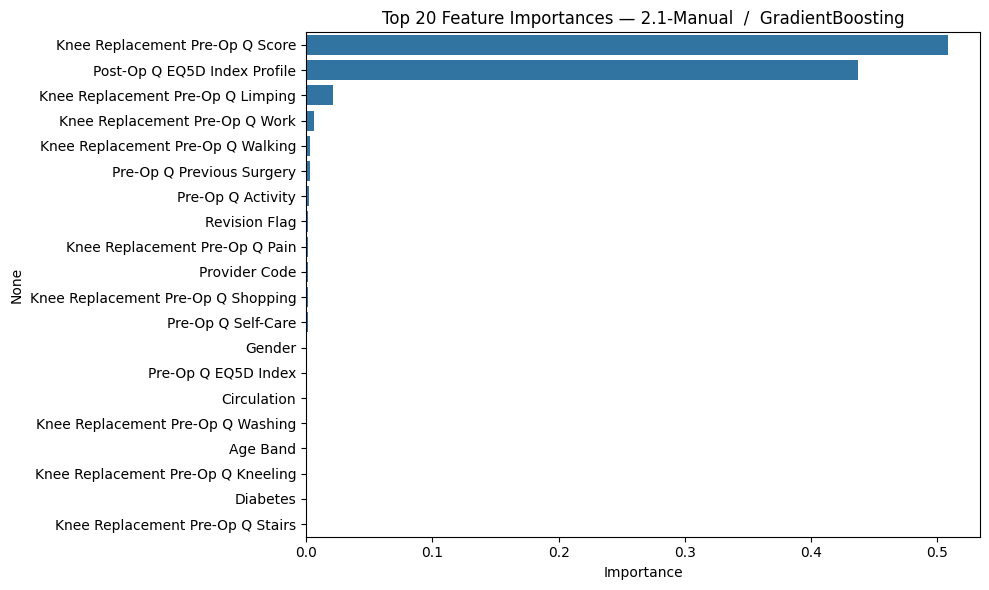


Running SHAP (may take a moment)...


100%|===================| 23575/23638 [01:55<00:00]        

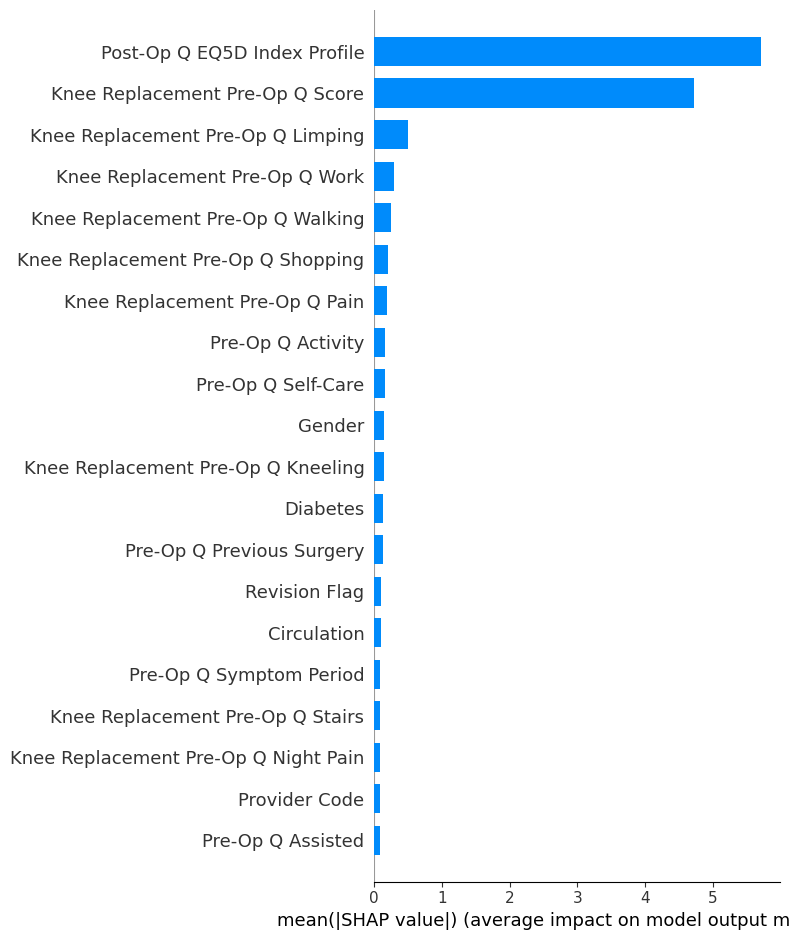

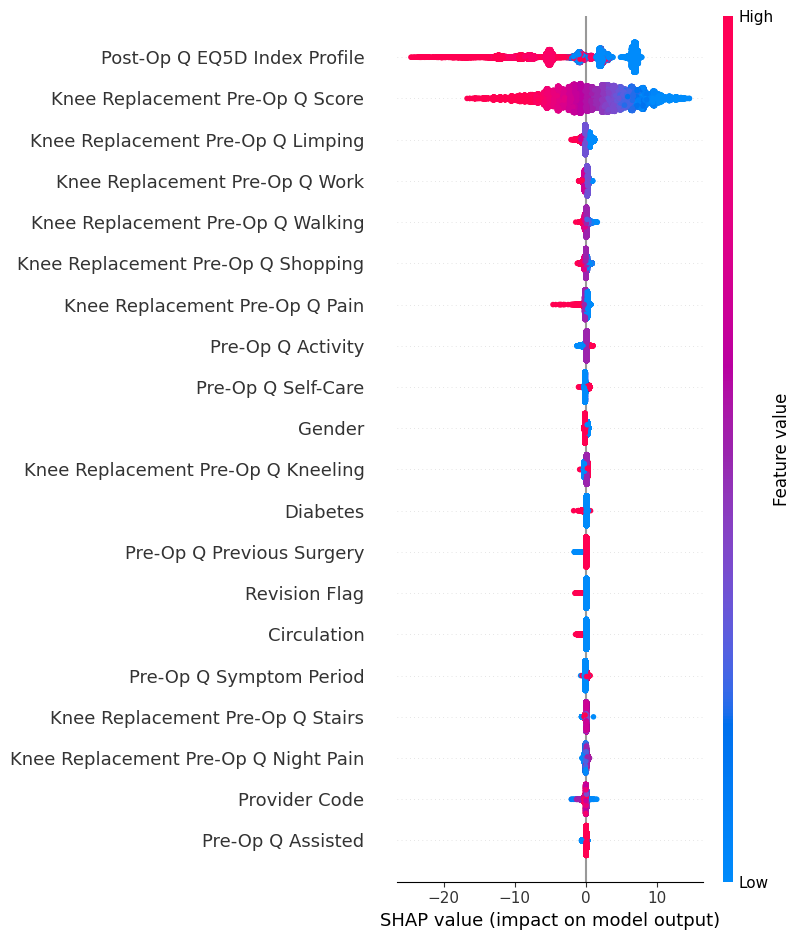

In [7]:

model_step   = best_pipeline.named_steps['model']
title_suffix = f'{best_dataset}  /  {best_name}'

# ── Tree models: feature importances ─────────────────────────────────────────
if hasattr(model_step, 'feature_importances_'):
    importances = (
        pd.Series(model_step.feature_importances_, index=feature_names)
        .sort_values(ascending=False)
    )
    print('Top 20 feature importances:')
    display(importances.head(20))

    plt.figure(figsize=(10, 6))
    sns.barplot(x=importances.head(20).values, y=importances.head(20).index)
    plt.title(f'Top 20 Feature Importances — {title_suffix}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

# ── Linear models: coefficients ───────────────────────────────────────────────
elif hasattr(model_step, 'coef_'):
    coef     = pd.Series(model_step.coef_, index=feature_names)
    coef_abs = coef.abs().sort_values(ascending=False)
    top25    = coef.loc[coef_abs.head(25).index].sort_values()

    print('Top 25 features by absolute coefficient:')
    display(coef.loc[coef_abs.head(25).index])

    colors = ['tomato' if v < 0 else 'steelblue' for v in top25]
    plt.figure(figsize=(10, 8))
    sns.barplot(x=top25.values, y=top25.index, palette=colors)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.title(f'Top 25 Feature Coefficients — {title_suffix}')
    plt.xlabel('Coefficient value')
    plt.tight_layout()
    plt.show()

else:
    print(f'No feature importance or coefficients for {best_name}.')

# ── SHAP — sklearn transform requires pandas ──────────────────────────────────
if shap is not None:
    print('\nRunning SHAP (may take a moment)...')
    X_train_t   = best_pipeline.named_steps['pre'].transform(X_train.to_pandas())
    X_test_t    = best_pipeline.named_steps['pre'].transform(X_test.to_pandas())
    explainer   = shap.Explainer(model_step, X_train_t)
    # check_additivity=False avoids a known numerical discrepancy with
    # HistGradientBoostingRegressor's internal tree representation
    shap_values = explainer(X_test_t, check_additivity=False)

    shap.summary_plot(shap_values, feature_names=feature_names, plot_type='bar', show=True)
    shap.summary_plot(shap_values, feature_names=feature_names, show=True)
else:
    print('SHAP not available — restart kernel and re-run to activate.')


## 4. Dummy Patient Prediction — Best Pipeline

Simulate a median/mode patient from the winning dataset's training data, predict their health gain, and explain the key drivers.

Dummy patient built from training set: 2.1-Manual  /  GradientBoosting

=== Dummy Patient Profile ===


Feature,Value
str,str
"""Provider Code""","""207.0"""
"""Procedure""","""1.0"""
"""Revision Flag""","""0.0"""
"""Year""","""2.0"""
"""Age Band""","""4.0"""
…,…
"""Knee Replacement Pre-Op Q Conf…","""2.0"""
"""Knee Replacement Pre-Op Q Shop…","""2.0"""
"""Knee Replacement Pre-Op Q Stai…","""2.0"""



>>> Predicted Health Gain : 17.9882
    Training set mean     : 16.9907
    This patient is ABOVE average by 0.9975 points

=== Top 10 most important features ===
  Feature                                       Patient value   Importance  % of total
  -------------------------------------------------------------------------------------
  Knee Replacement Pre-Op Q Score               19.0                0.5083       50.8%
  Post-Op Q EQ5D Index Profile                  11221.0             0.4369       43.7%
  Knee Replacement Pre-Op Q Limping             1.0                 0.0216        2.2%
  Knee Replacement Pre-Op Q Work                1.0                 0.0060        0.6%
  Knee Replacement Pre-Op Q Walking             2.0                 0.0033        0.3%
  Pre-Op Q Previous Surgery                     2.0                 0.0029        0.3%
  Pre-Op Q Activity                             2.0                 0.0022        0.2%
  Revision Flag                                 0.0 

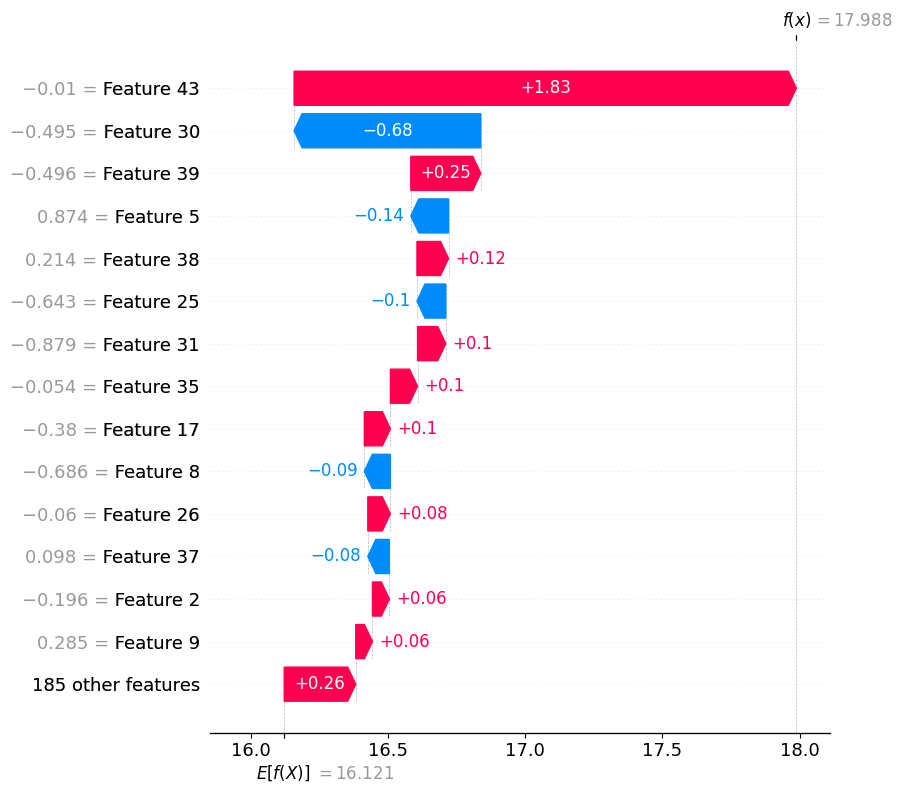


=== Plain English Summary ===
Dataset '2.1-Manual' with model 'GradientBoosting' predicts this patient will
gain 17.99 points on the knee health score after surgery.
This is higher than the average gain of 16.99 in that training set.


In [10]:

print(f'Dummy patient built from training set: {best_dataset}  /  {best_name}\n')

# ── Build representative patient using Polars native operations ───────────────
dummy_data = {}
for col in numeric_cols:
    dummy_data[col] = [X_train[col].median()]          # Polars returns a scalar
for col in cat_cols:
    mode_series = X_train[col].mode()
    dummy_data[col] = [mode_series[0] if len(mode_series) > 0 else None]

# Keep as Polars DataFrame for consistency.
# Convert to pandas only at the sklearn boundary.
dummy_pl = pl.DataFrame(dummy_data)
dummy_pd = dummy_pl.to_pandas()      # sklearn boundary

print('=== Dummy Patient Profile ===')
display(dummy_pl.transpose(include_header=True, header_name='Feature', column_names=['Value']))

# ── Predict (sklearn boundary) ────────────────────────────────────────────────
predicted_gain = best_pipeline.predict(dummy_pd)[0]
avg_gain       = float(np.mean(y_train))
diff           = predicted_gain - avg_gain
direction      = 'ABOVE' if diff > 0 else 'BELOW'

print(f'\n>>> Predicted Health Gain : {predicted_gain:.4f}')
print(f'    Training set mean     : {avg_gain:.4f}')
print(f'    This patient is {direction} average by {abs(diff):.4f} points\n')

# ── Explain contributions ─────────────────────────────────────────────────────
model_step = best_pipeline.named_steps['model']

if hasattr(model_step, 'coef_'):
    transformed   = best_pipeline.named_steps['pre'].transform(dummy_pd)[0]
    contributions = pd.Series(model_step.coef_ * transformed, index=feature_names)
    total_abs     = contributions.abs().sum()

    top_pos = contributions.sort_values(ascending=False).head(5)
    top_neg = contributions.sort_values().head(5)

    print('=== Top 5 features INCREASING the predicted health gain ===')
    print(f'  {"Feature":<45} {"Raw value":<12} {"Contribution":>12}  {"% of total":>10}')
    print('  ' + '-' * 85)
    for feat, val in top_pos.items():
        raw  = dummy_pl[feat][0] if feat in dummy_pl.columns else 'encoded'
        pct  = 100 * val / total_abs
        print(f'  + {feat:<45} {str(raw):<12} {val:>+12.4f}  {pct:>9.1f}%')

    print(f'\n=== Top 5 features DECREASING the predicted health gain ===')
    print(f'  {"Feature":<45} {"Raw value":<12} {"Contribution":>12}  {"% of total":>10}')
    print('  ' + '-' * 85)
    for feat, val in top_neg.items():
        raw  = dummy_pl[feat][0] if feat in dummy_pl.columns else 'encoded'
        pct  = 100 * val / total_abs
        print(f'  - {feat:<45} {str(raw):<12} {val:>+12.4f}  {pct:>9.1f}%')

    # Bar chart — top 20 by absolute contribution with % labels
    sorted_contrib = contributions.abs().sort_values(ascending=False).head(20)
    bar_vals = contributions[sorted_contrib.index]
    bar_pcts = 100 * bar_vals / total_abs
    bar_colors = ['steelblue' if v >= 0 else 'tomato' for v in bar_vals]

    fig, ax = plt.subplots(figsize=(11, 6))
    bars = ax.barh(sorted_contrib.index[::-1], bar_vals.iloc[::-1], color=bar_colors[::-1])
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Feature Contributions — {best_dataset}  /  {best_name}')
    ax.set_xlabel('Contribution  (coef × scaled value)')
    # Annotate each bar with its percentage
    for bar, pct in zip(bars, bar_pcts.iloc[::-1]):
        x_pos = bar.get_width()
        ax.text(
            x_pos + (0.002 * ax.get_xlim()[1] if x_pos >= 0 else -0.002 * ax.get_xlim()[1]),
            bar.get_y() + bar.get_height() / 2,
            f'{pct:+.1f}%',
            va='center', ha='left' if x_pos >= 0 else 'right', fontsize=8,
        )
    plt.tight_layout()
    plt.show()

elif hasattr(model_step, 'feature_importances_'):
    importances  = pd.Series(model_step.feature_importances_, index=feature_names).sort_values(ascending=False)
    total_imp    = importances.sum()
    print('=== Top 10 most important features ===')
    print(f'  {"Feature":<45} {"Patient value":<15} {"Importance":>10}  {"% of total":>10}')
    print('  ' + '-' * 85)
    for feat, imp in importances.head(10).items():
        raw = dummy_pl[feat][0] if feat in dummy_pl.columns else 'encoded'
        pct = 100 * imp / total_imp
        print(f'  {feat:<45} {str(raw):<15} {imp:>10.4f}  {pct:>9.1f}%')

# ── SHAP waterfall with % contribution (sklearn boundary: .to_pandas()) ───────
if shap is not None:
    X_train_t = best_pipeline.named_steps['pre'].transform(X_train.to_pandas())
    X_dummy_t = best_pipeline.named_steps['pre'].transform(dummy_pd)
    explainer = shap.Explainer(model_step, X_train_t)
    # check_additivity=False avoids a known numerical discrepancy with
    # HistGradientBoostingRegressor's internal tree representation
    shap_vals = explainer(X_dummy_t, check_additivity=False)

    # SHAP percentage contribution table
    sv        = shap_vals[0].values                        # shape: (n_features,)
    total_abs_shap = np.abs(sv).sum()
    shap_ser  = pd.Series(sv, index=feature_names)
    shap_top  = shap_ser.abs().sort_values(ascending=False).head(15)

    print('\n=== SHAP Feature Contributions (%) for Dummy Patient ===')
    print(f'  {"Feature":<45} {"SHAP value":>12}  {"% of |SHAP| total":>18}')
    print('  ' + '-' * 80)
    for feat in shap_top.index:
        val = shap_ser[feat]
        pct = 100 * abs(val) / total_abs_shap
        sign = '+' if val >= 0 else '-'
        print(f'  {sign} {feat:<44} {val:>+12.4f}  {pct:>17.1f}%')

    print('\n=== SHAP Waterfall (dummy patient) ===')
    shap.plots.waterfall(shap_vals[0], max_display=15, show=True)
else:
    print('\nTip: restart kernel and re-run to enable SHAP waterfall.')

print('\n=== Plain English Summary ===')
print(f"Dataset '{best_dataset}' with model '{best_name}' predicts this patient will")
print(f"gain {predicted_gain:.2f} points on the knee health score after surgery.")
print(f"This is {'higher' if diff > 0 else 'lower'} than the average gain of {avg_gain:.2f} in that training set.")


## 5. Save All Models and Metrics

Save the best pipeline for **each dataset** and a combined comparison CSV.

In [9]:

out_dir = Path('./models')
out_dir.mkdir(parents=True, exist_ok=True)

# ── Save every (dataset × model) pipeline ────────────────────────────────────
for ds_label, models_dict in all_results.items():
    for mdl_name, res in models_dict.items():
        safe_label = ds_label.replace('/', '-').replace(' ', '_')
        pipe_path  = out_dir / f'3.1-{safe_label}-{mdl_name}.joblib'
        joblib.dump(res['pipeline'], pipe_path)
        print(f'Saved: {pipe_path}')

# ── Save comparison CSV ───────────────────────────────────────────────────────
comparison_path = out_dir / '3.1-comparison-metrics.csv'
comparison_df.to_csv(comparison_path, index=False)
print(f'\nSaved comparison table: {comparison_path}')

# ── Print final winner ────────────────────────────────────────────────────────
print(f'\n{"=" * 50}')
print(f'  OVERALL WINNER')
print(f'  Dataset  : {best_dataset}')
print(f'  Model    : {best_name}')
print(f'  Test RMSE: {winner_row["Test RMSE"]}  |  R²: {winner_row["Test R²"]}')
print(f'{"=" * 50}')


Saved: models\3.1-2.1-Manual-LinearRegression.joblib
Saved: models\3.1-2.1-Manual-Ridge.joblib
Saved: models\3.1-2.1-Manual-Lasso.joblib
Saved: models\3.1-2.1-Manual-RandomForest.joblib
Saved: models\3.1-2.1-Manual-GradientBoosting.joblib
Saved: models\3.1-2.1-Manual-XGBoost.joblib
Saved: models\3.1-2.2-UMAP-MICE-LinearRegression.joblib
Saved: models\3.1-2.2-UMAP-MICE-Ridge.joblib
Saved: models\3.1-2.2-UMAP-MICE-Lasso.joblib
Saved: models\3.1-2.2-UMAP-MICE-XGBoost.joblib

Saved comparison table: models\3.1-comparison-metrics.csv

  OVERALL WINNER
  Dataset  : 2.1-Manual
  Model    : GradientBoosting
  Test RMSE: 5.5348  |  R²: 0.6817
